In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path

import polars as pl

from sailpack.export_load_case_mapping_seed import (
    build_records as build_mapping_records,
)
from sailpack.export_reference_values_seed import (
    build_reference_records,
)
from sailpack.parse import parse_directory
from sailpack.seed_utils import (
    build_load_case_records,
    extract_load_cases,
    read_reference_values_mapping,
)

sailpack_dir = Path("../sailpack")
load_cases_dir = sailpack_dir / "load_cases"
result = parse_directory(load_cases_dir)
# result.group_by(["source_file", "table_description"]).n_unique()

# Show conditions

calculation_id,tws,twa,aws,awa,bsp,heel
str,f64,f64,f64,f64,f64,f64
"""LC1-2_ B_FM_FMZ_TWA45_TWS14_RM…",14.0,-42.8,23.82,21.0,12.0,22.0
"""LC3_ B_M1R_MZ1R_TWA45_TWS19_RM…",19.0,-41.5,28.97,23.0,12.5,22.0
"""LC1-2R_ B_FM_FMZ_TWA110_TWS18_…",20.0,-83.0,28.04,44.1,17.7,22.0
"""LC12_ SJ_M2R_TWA52_TWS30_RM15_…",30.0,-52.0,38.73,35.3,13.2,15.0
"""LC___FM_B_TWA45_TWS18_RM22_202…",18.0,-42.8,28.02,23.6,12.5,22.0
…,…,…,…,…,…,…
"""LC5-R_ SS_M1R_MZ1R_TWA110_TWS2…",23.0,-82.8,30.85,46.7,18.3,20.0
"""LC22_ B_FM_FMZ_MZJ_ TWA55_TWS1…",14.0,-50.3,24.77,23.5,13.8,22.0
"""LC7_ SS_M2R_MZ2R_TWA45_TWS26_R…",27.0,-39.9,36.83,25.8,12.5,20.0


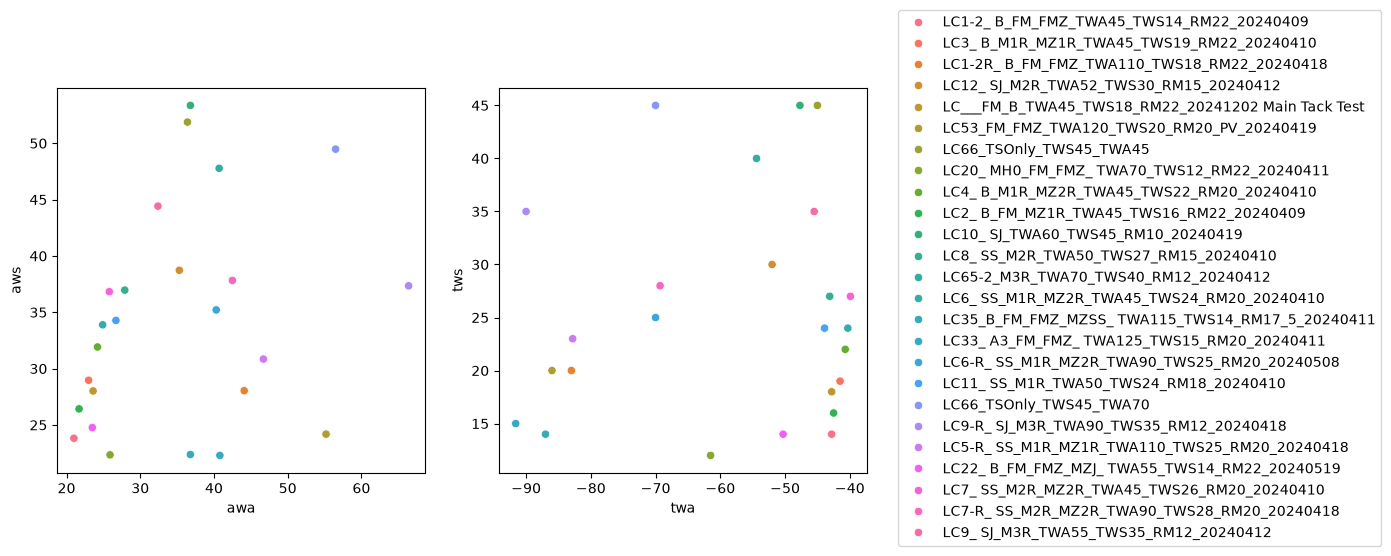

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

conditions = extract_load_cases(result)
df = conditions.to_pandas(use_pyarrow_extension_array=True)

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(data=df, x="awa", y="aws", hue="calculation_id", ax=ax, legend=True)
sns.scatterplot(data=df, x="twa", y="tws", hue="calculation_id", ax=ax2, legend=False)

handles, labels = ax.get_legend_handles_labels()
ax.get_legend().remove()
fig.subplots_adjust(right=0.8)
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(0.82, 0.5))

conditions

## Map to Loads app

In [14]:
mapping = read_reference_values_mapping(sailpack_dir)
mapping

Variable key,Technical name,name in LC sheet by Stevo,Sailpack table name,Sailpack row label,Sailpack column label,Note on getting var from Sailpack
str,str,str,str,str,str,str
"""aft-winch-load-ps""","""aft-winch-load-ps""","""Trisail Sheet""","""CABLE DATA""","""CABLE_TRISAIL_SHEET_PORT""","""Load (N)""","""May also carry loads from oth…"
"""aft-winch-load-sb""","""aft-winch-load-sb""","""Trisail Sheet""","""CABLE DATA""","""CABLE_TRISAIL_SHEET_PORT""","""Load (N)""","""May also carry loads from oth…"
"""aft-winch-load""","""aft-winch-load-sb""","""Trisail Sheet""","""CABLE DATA""","""CABLE_TRISAIL_SHEET_STBD""","""Load (N)""","""May also carry loads from othe…"
"""aft-winch-load""","""aft-winch-load-ps""","""Mizzen jib sheet load""","""CABLE DATA""","""CABLE_MIZZEN_JIB_SHEET""","""Load (N)""",null
"""blade-adjuster-load""","""blade-adjuster-load""","""Main head stay""","""CABLE DATA""","""CABLE__FS""","""Load (N)""",null
…,…,…,…,…,…,…
"""mizzen-outhaul-relative-positi…","""mizzen-outhaul-relative-positi…","""Mizzen outhaul / REEF""","""CABLE DATA""","""CABLE_MIZZENCLEW""","""Trimming value (N or m)""",null
"""mizzen-preventer-load""","""mizzen-preventer-load""","""Mizzen Preventer sheet""","""CABLE DATA""","""CABLE_MIZZEN_PREVENTER""","""Load (N)""",null
"""mizzen-runner-load""","""mizzen-runner-load-ps""","""Mizzen runner (remap?)""","""CABLE DATA""","""CABLE_MIZZ_RUNNER""","""Load (N)""","""2 x Mizzen Runner Tail Load Pi…"


In [16]:
load_case_records = build_load_case_records(result)
reference_records = build_reference_records(result, mapping)
mapping_records = build_mapping_records(load_cases_dir)


load_cases = pl.DataFrame(load_case_records)
reference_values = pl.DataFrame(reference_records)
load_case_mapping = pl.DataFrame(mapping_records)

load_cases, reference_values, load_case_mapping

(shape: (23, 9)
 ┌───────────────────┬───────────────────┬──────┬───────┬───┬──────┬──────┬──────┬──────────────────┐
 │ id                ┆ name              ┆ tws  ┆ twa   ┆ … ┆ awa  ┆ bsp  ┆ heel ┆ sail_abbreviatio │
 │ ---               ┆ ---               ┆ ---  ┆ ---   ┆   ┆ ---  ┆ ---  ┆ ---  ┆ ns               │
 │ str               ┆ str               ┆ f64  ┆ f64   ┆   ┆ f64  ┆ f64  ┆ f64  ┆ ---              │
 │                   ┆                   ┆      ┆       ┆   ┆      ┆      ┆      ┆ list[str]        │
 ╞═══════════════════╪═══════════════════╪══════╪═══════╪═══╪══════╪══════╪══════╪══════════════════╡
 │ LC65-2_M3R_TWA70_ ┆ LC65-2_M3R_TWA70_ ┆ 40.0 ┆ -54.4 ┆ … ┆ 40.7 ┆ 13.0 ┆ 12.0 ┆ ["M3R"]          │
 │ TWS40_RM12_20…    ┆ TWS40_RM12_20…    ┆      ┆       ┆   ┆      ┆      ┆      ┆                  │
 │ LC10_ SJ_TWA60_TW ┆ LC10_ SJ_TWA60_TW ┆ 45.0 ┆ -47.7 ┆ … ┆ 36.8 ┆ 12.5 ┆ 10.0 ┆ ["SJ"]           │
 │ S45_RM10_2024…    ┆ S45_RM10_2024…    ┆      ┆       ┆   ┆     

In [19]:
reference_values

load_case_id,variable_key,target,alarm_low,warning_low,warning_high,alarm_high
str,str,f64,null,null,null,null
"""LC65-2_M3R_TWA70_TWS40_RM12_20…","""fiber-optic-mizzen-v1-sb""",25.660343,null,null,null,null
"""LC9_ SJ_M3R_TWA55_TWS35_RM12_2…","""fiber-optic-mizzen-v1-sb""",25.659629,null,null,null,null
"""LC7-R_ SS_M2R_MZ2R_TWA90_TWS28…","""fiber-optic-mizzen-v1-sb""",14.021302,null,null,null,null
"""LC20_ MH0_FM_FMZ_ TWA70_TWS12_…","""fiber-optic-mizzen-v1-sb""",13.785238,null,null,null,null
"""LC66_TSOnly_TWS45_TWA70""","""fiber-optic-mizzen-v1-sb""",27.533459,null,null,null,null
…,…,…,…,…,…,…
"""LC53_FM_FMZ_TWA120_TWS20_RM20_…","""mizzen-runner-combined-load""",2.711221,null,null,null,null
"""LC___FM_B_TWA45_TWS18_RM22_202…","""mizzen-runner-combined-load""",7.922787,null,null,null,null
"""LC22_ B_FM_FMZ_MZJ_ TWA55_TWS1…","""mizzen-runner-combined-load""",8.254705,null,null,null,null
